# ASCON First-Round Key Reconstruction from x′0 and x′1

This notebook combines the completed x′0 and x′1 CPA/DPA result files to reconstruct the ASCON key under the first-round leakage model.

It reads:

```text
x0_clean_cpa_dpa_results_N50000_samples0_12000_stride1.csv
x1_clean_cpa_dpa_results_N50000_samples0_12000_stride1.csv
```

Then it reconstructs:

```text
x′0 result  → K0
x′1 result  → K0 XOR K1 XOR RC
K1          → K0 XOR relation XOR RC
Full key    → K0 || K1
```

Expected final key:

```text
00112233445566778899aabbccddeeff
```

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Imports OK")

Imports OK


## 1. Set paths

In [2]:
ASCON_ROOT = Path(r"C:\Users\thetp\Downloads\ASCON_FYP")

X0_RESULTS_DIR = ASCON_ROOT / "04_Results" / "first_round_dpa" / "clean_50000_x0_cpa_dpa"
X1_RESULTS_DIR = ASCON_ROOT / "04_Results" / "first_round_dpa" / "clean_50000_x1_cpa_dpa"

X0_RESULTS_PATH = X0_RESULTS_DIR / "x0_clean_cpa_dpa_results_N50000_samples0_12000_stride1.csv"
X1_RESULTS_PATH = X1_RESULTS_DIR / "x1_clean_cpa_dpa_results_N50000_samples0_12000_stride1.csv"

OUT_DIR = ASCON_ROOT / "04_Results" / "first_round_dpa" / "key_reconstruction_from_x0_x1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert X0_RESULTS_PATH.exists(), f"x0 result file not found: {X0_RESULTS_PATH}"
assert X1_RESULTS_PATH.exists(), f"x1 result file not found: {X1_RESULTS_PATH}"

print("X0_RESULTS_PATH:", X0_RESULTS_PATH)
print("X1_RESULTS_PATH:", X1_RESULTS_PATH)
print("OUT_DIR:", OUT_DIR)

X0_RESULTS_PATH: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x0_cpa_dpa\x0_clean_cpa_dpa_results_N50000_samples0_12000_stride1.csv
X1_RESULTS_PATH: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x1_cpa_dpa\x1_clean_cpa_dpa_results_N50000_samples0_12000_stride1.csv
OUT_DIR: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1


## 2. Load x′0 and x′1 result files

In [3]:
x0_df = pd.read_csv(X0_RESULTS_PATH)
x1_df = pd.read_csv(X1_RESULTS_PATH)

print("x0_df shape:", x0_df.shape)
print("x1_df shape:", x1_df.shape)

display(x0_df.head())
display(x1_df.head())

x0_df shape: (128, 18)
x1_df shape: (128, 18)


,label,target,mode,method,shuffle_nonce,N_USE,sample_start,sample_end,sample_stride,bit_i,true_candidate,best_candidate,true_rank,best_score,true_score,best_sample_original,true_best_sample_original,candidate_scores
0,clean_50000_x0,x0_prime,firmware,CPA,False,50000,0,12000,1,0,4,4,1,0.226388,0.226388,11131,11131,"[0.017304135486483574, 0.01522328145802021, 0...."
1,clean_50000_x0,x0_prime,firmware,DPA,False,50000,0,12000,1,0,4,4,1,0.010325,0.010325,11130,11130,"[0.000680282711982727, 0.00043555721640586853,..."
2,clean_50000_x0,x0_prime,firmware,CPA,False,50000,0,12000,1,1,4,4,1,0.213406,0.213406,11131,11131,"[0.018043924123048782, 0.01797705516219139, 0...."
3,clean_50000_x0,x0_prime,firmware,DPA,False,50000,0,12000,1,1,4,4,1,0.009565,0.009565,11130,11130,"[0.00044894497841596603, 0.000661410391330719,..."
4,clean_50000_x0,x0_prime,firmware,CPA,False,50000,0,12000,1,2,2,2,1,0.243428,0.243428,4805,4805,"[0.01840069703757763, 0.017136821523308754, 0...."


,label,target,mode,method,shuffle_nonce,N_USE,sample_start,sample_end,sample_stride,bit_i,true_candidate,best_candidate,true_rank,best_score,true_score,best_sample_original,true_best_sample_original,candidate_scores
0,clean_50000_x1,x1_prime,firmware,CPA,False,50000,0,12000,1,0,4,4,1,0.344836,0.344836,11613,11613,"[0.018538201227784157, 0.016670657321810722, 0..."
1,clean_50000_x1,x1_prime,firmware,DPA,False,50000,0,12000,1,0,4,4,1,0.009959,0.009959,11614,11614,"[0.000642731785774231, 0.0004918873310089111, ..."
2,clean_50000_x1,x1_prime,firmware,CPA,False,50000,0,12000,1,1,0,0,1,0.305802,0.305802,11610,11610,"[0.30580204725265503, 0.11213835328817368, 0.0..."
3,clean_50000_x1,x1_prime,firmware,DPA,False,50000,0,12000,1,1,0,0,1,0.008927,0.008927,11890,11890,"[0.008926570415496826, 0.003589436411857605, 0..."
4,clean_50000_x1,x1_prime,firmware,CPA,False,50000,0,12000,1,2,2,2,1,0.299338,0.299338,11891,11891,"[0.017959922552108765, 0.0175007414072752, 0.2..."


In [4]:
for name, df in [("x0", x0_df), ("x1", x1_df)]:
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print("target:", df["target"].unique())
    print("mode:", df["mode"].unique())
    print("methods:", df["method"].unique())
    print("shuffle_nonce:", df["shuffle_nonce"].unique())
    print("N_USE:", df["N_USE"].unique())
    print("bit_i unique:", df["bit_i"].nunique())
    print("true_rank counts:")
    print(df["true_rank"].value_counts().sort_index())


x0
target: ['x0_prime']
mode: ['firmware']
methods: ['CPA' 'DPA']
shuffle_nonce: [False]
N_USE: [50000]
bit_i unique: 64
true_rank counts:
true_rank
1    128
Name: count, dtype: int64

x1
target: ['x1_prime']
mode: ['firmware']
methods: ['CPA' 'DPA']
shuffle_nonce: [False]
N_USE: [50000]
bit_i unique: 64
true_rank counts:
true_rank
1    128
Name: count, dtype: int64


## 3. Helper functions

In [5]:
def candidate_to_bits(cand):
    cand = int(cand)
    return [(cand >> 0) & 1, (cand >> 1) & 1, (cand >> 2) & 1]

def x0_indices(i, mode="firmware"):
    if mode == "firmware":
        return [i, i + 19, i + 28]
    elif mode == "paper":
        return [i, i + 45, i + 36]
    raise ValueError("mode must be firmware or paper")

def x1_indices(i, mode="firmware"):
    if mode == "firmware":
        return [i, i + 61, i + 39]
    elif mode == "paper":
        return [i, i + 3, i + 25]
    raise ValueError("mode must be firmware or paper")

def bits_to_uint64_le(bits):
    x = 0
    for j, b in enumerate(bits):
        x |= (int(b) & 1) << j
    return x

def uint64_to_bits(x):
    return [(int(x) >> j) & 1 for j in range(64)]

def uint64_to_le_hex(x):
    return int(x).to_bytes(8, byteorder="little").hex()

def load64_le_from_bytes(b, offset_bytes):
    x = 0
    for i in range(8):
        x |= int(b[offset_bytes + i]) << (8 * i)
    return x

def reconstruct_word_from_candidate_rows(df, target="x0", method="CPA", mode="firmware", use_column="best_candidate"):
    d = df[
        (df["method"] == method) &
        (df["mode"] == mode) &
        (df["shuffle_nonce"] == False)
    ].copy()

    assert len(d) == 64, f"Expected 64 rows for {target} {method} {mode}, got {len(d)}"

    bit_votes = {j: [] for j in range(64)}

    for _, row in d.iterrows():
        i = int(row["bit_i"])
        cand = int(row[use_column])
        c_bits = candidate_to_bits(cand)

        if target == "x0":
            idxs = x0_indices(i, mode)
        elif target == "x1":
            idxs = x1_indices(i, mode)
        else:
            raise ValueError("target must be x0 or x1")

        for idx, bit in zip(idxs, c_bits):
            bit_votes[idx % 64].append(int(bit))

    recovered_bits = []
    consistency_rows = []

    for j in range(64):
        votes = bit_votes[j]
        zeros = votes.count(0)
        ones = votes.count(1)

        if ones > zeros:
            recovered_bit = 1
        elif zeros > ones:
            recovered_bit = 0
        else:
            recovered_bit = -1

        recovered_bits.append(recovered_bit)

        consistency_rows.append({
            "bit_position": j,
            "votes": str(votes),
            "num_votes": len(votes),
            "zeros": zeros,
            "ones": ones,
            "recovered_bit": recovered_bit,
            "consistent": (zeros == 0 or ones == 0)
        })

    consistency_df = pd.DataFrame(consistency_rows)

    if any(b == -1 for b in recovered_bits):
        raise ValueError("Tie found in bit reconstruction. Check consistency_df.")

    recovered_word = bits_to_uint64_le(recovered_bits)
    return recovered_word, recovered_bits, consistency_df

print("Helper functions ready")

Helper functions ready


## 4. Set known fixed key for verification

In [6]:
TRUE_KEY_HEX = "00112233445566778899aabbccddeeff"
TRUE_KEY_BYTES = bytes.fromhex(TRUE_KEY_HEX)

TRUE_K0 = load64_le_from_bytes(TRUE_KEY_BYTES, 0)
TRUE_K1 = load64_le_from_bytes(TRUE_KEY_BYTES, 8)

RC = 0xF0
TRUE_RELATION = TRUE_K0 ^ TRUE_K1 ^ RC

print("TRUE_KEY_HEX:", TRUE_KEY_HEX)
print("TRUE_K0 little-endian word:", hex(TRUE_K0), "| bytes:", uint64_to_le_hex(TRUE_K0))
print("TRUE_K1 little-endian word:", hex(TRUE_K1), "| bytes:", uint64_to_le_hex(TRUE_K1))
print("TRUE_RELATION = K0 XOR K1 XOR RC:", hex(TRUE_RELATION), "| bytes:", uint64_to_le_hex(TRUE_RELATION))

TRUE_KEY_HEX: 00112233445566778899aabbccddeeff
TRUE_K0 little-endian word: 0x7766554433221100 | bytes: 0011223344556677
TRUE_K1 little-endian word: 0xffeeddccbbaa9988 | bytes: 8899aabbccddeeff
TRUE_RELATION = K0 XOR K1 XOR RC: 0x8888888888888878 | bytes: 7888888888888888


## 5. Reconstruct key from x′0 and x′1

In [7]:
METHODS = ["CPA", "DPA"]
MODE = "firmware"

summary_rows = []
bit_tables = {}

for method in METHODS:
    print("\n" + "=" * 100)
    print("Reconstructing using method:", method)
    print("=" * 100)

    rec_k0, rec_k0_bits, k0_consistency = reconstruct_word_from_candidate_rows(
        x0_df, target="x0", method=method, mode=MODE, use_column="best_candidate"
    )

    rec_relation, rec_relation_bits, relation_consistency = reconstruct_word_from_candidate_rows(
        x1_df, target="x1", method=method, mode=MODE, use_column="best_candidate"
    )

    rec_k1 = rec_k0 ^ rec_relation ^ RC
    rec_key_hex = uint64_to_le_hex(rec_k0) + uint64_to_le_hex(rec_k1)

    k0_match = (rec_k0 == TRUE_K0)
    relation_match = (rec_relation == TRUE_RELATION)
    k1_match = (rec_k1 == TRUE_K1)
    key_match = (rec_key_hex.lower() == TRUE_KEY_HEX.lower())

    print("Recovered K0:", hex(rec_k0), "| bytes:", uint64_to_le_hex(rec_k0), "| match:", k0_match)
    print("Recovered relation:", hex(rec_relation), "| bytes:", uint64_to_le_hex(rec_relation), "| match:", relation_match)
    print("Recovered K1:", hex(rec_k1), "| bytes:", uint64_to_le_hex(rec_k1), "| match:", k1_match)
    print("Recovered full key:", rec_key_hex, "| match:", key_match)

    print("K0 consistency:", k0_consistency["consistent"].sum(), "/ 64 bits consistent")
    print("Relation consistency:", relation_consistency["consistent"].sum(), "/ 64 bits consistent")

    summary_rows.append({
        "method": method,
        "mode": MODE,
        "recovered_k0_hex_word": hex(rec_k0),
        "recovered_k0_bytes_hex": uint64_to_le_hex(rec_k0),
        "true_k0_bytes_hex": uint64_to_le_hex(TRUE_K0),
        "k0_match": bool(k0_match),
        "recovered_relation_hex_word": hex(rec_relation),
        "recovered_relation_bytes_hex": uint64_to_le_hex(rec_relation),
        "true_relation_bytes_hex": uint64_to_le_hex(TRUE_RELATION),
        "relation_match": bool(relation_match),
        "recovered_k1_hex_word": hex(rec_k1),
        "recovered_k1_bytes_hex": uint64_to_le_hex(rec_k1),
        "true_k1_bytes_hex": uint64_to_le_hex(TRUE_K1),
        "k1_match": bool(k1_match),
        "recovered_key_hex": rec_key_hex,
        "true_key_hex": TRUE_KEY_HEX,
        "full_key_match": bool(key_match),
        "k0_consistent_bits_out_of_64": int(k0_consistency["consistent"].sum()),
        "relation_consistent_bits_out_of_64": int(relation_consistency["consistent"].sum())
    })

    bit_tables[(method, "k0")] = k0_consistency
    bit_tables[(method, "relation")] = relation_consistency

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


Reconstructing using method: CPA
Recovered K0: 0x7766554433221100 | bytes: 0011223344556677 | match: True
Recovered relation: 0x8888888888888878 | bytes: 7888888888888888 | match: True
Recovered K1: 0xffeeddccbbaa9988 | bytes: 8899aabbccddeeff | match: True
Recovered full key: 00112233445566778899aabbccddeeff | match: True
K0 consistency: 64 / 64 bits consistent
Relation consistency: 64 / 64 bits consistent

Reconstructing using method: DPA
Recovered K0: 0x7766554433221100 | bytes: 0011223344556677 | match: True
Recovered relation: 0x8888888888888878 | bytes: 7888888888888888 | match: True
Recovered K1: 0xffeeddccbbaa9988 | bytes: 8899aabbccddeeff | match: True
Recovered full key: 00112233445566778899aabbccddeeff | match: True
K0 consistency: 64 / 64 bits consistent
Relation consistency: 64 / 64 bits consistent


,method,mode,recovered_k0_hex_word,recovered_k0_bytes_hex,true_k0_bytes_hex,k0_match,recovered_relation_hex_word,recovered_relation_bytes_hex,true_relation_bytes_hex,relation_match,recovered_k1_hex_word,recovered_k1_bytes_hex,true_k1_bytes_hex,k1_match,recovered_key_hex,true_key_hex,full_key_match,k0_consistent_bits_out_of_64,relation_consistent_bits_out_of_64
0,CPA,firmware,0x7766554433221100,0011223344556677,0011223344556677,True,0x8888888888888878,7888888888888888,7888888888888888,True,0xffeeddccbbaa9988,8899aabbccddeeff,8899aabbccddeeff,True,00112233445566778899aabbccddeeff,00112233445566778899aabbccddeeff,True,64,64
1,DPA,firmware,0x7766554433221100,0011223344556677,0011223344556677,True,0x8888888888888878,7888888888888888,7888888888888888,True,0xffeeddccbbaa9988,8899aabbccddeeff,8899aabbccddeeff,True,00112233445566778899aabbccddeeff,00112233445566778899aabbccddeeff,True,64,64


## 6. Save reconstruction results

In [8]:
summary_csv = OUT_DIR / "ascon_key_reconstruction_summary_from_x0_x1.csv"
summary_json = OUT_DIR / "ascon_key_reconstruction_summary_from_x0_x1.json"

summary_df.to_csv(summary_csv, index=False)

with open(summary_json, "w") as f:
    json.dump(summary_df.to_dict(orient="records"), f, indent=4)

print("Saved summary CSV:", summary_csv)
print("Saved summary JSON:", summary_json)

for (method, name), table in bit_tables.items():
    out = OUT_DIR / f"bit_vote_consistency_{method}_{name}.csv"
    table.to_csv(out, index=False)
    print("Saved:", out)

Saved summary CSV: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\ascon_key_reconstruction_summary_from_x0_x1.csv
Saved summary JSON: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\ascon_key_reconstruction_summary_from_x0_x1.json
Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\bit_vote_consistency_CPA_k0.csv
Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\bit_vote_consistency_CPA_relation.csv
Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\bit_vote_consistency_DPA_k0.csv
Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\bit_vote_consistency_DPA_relation.csv


## 7. Human-readable thesis table

In [9]:
thesis_table = summary_df[[
    "method",
    "recovered_k0_bytes_hex",
    "k0_match",
    "recovered_relation_bytes_hex",
    "relation_match",
    "recovered_k1_bytes_hex",
    "k1_match",
    "recovered_key_hex",
    "full_key_match"
]].copy()

display(thesis_table)

thesis_table_csv = OUT_DIR / "ascon_key_reconstruction_thesis_table.csv"
thesis_table.to_csv(thesis_table_csv, index=False)

print("Saved thesis table:", thesis_table_csv)

,method,recovered_k0_bytes_hex,k0_match,recovered_relation_bytes_hex,relation_match,recovered_k1_bytes_hex,k1_match,recovered_key_hex,full_key_match
0,CPA,0011223344556677,True,7888888888888888,True,8899aabbccddeeff,True,00112233445566778899aabbccddeeff,True
1,DPA,0011223344556677,True,7888888888888888,True,8899aabbccddeeff,True,00112233445566778899aabbccddeeff,True


Saved thesis table: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\ascon_key_reconstruction_thesis_table.csv


## 8. Optional visual check: recovered bit agreement

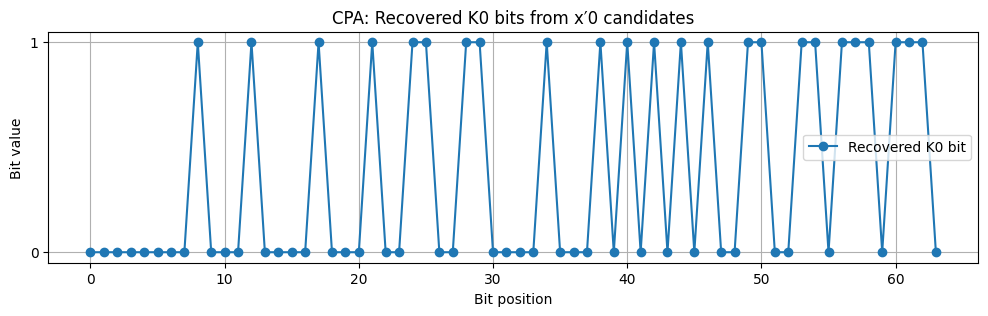

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\figure_recovered_k0_bits_CPA.png


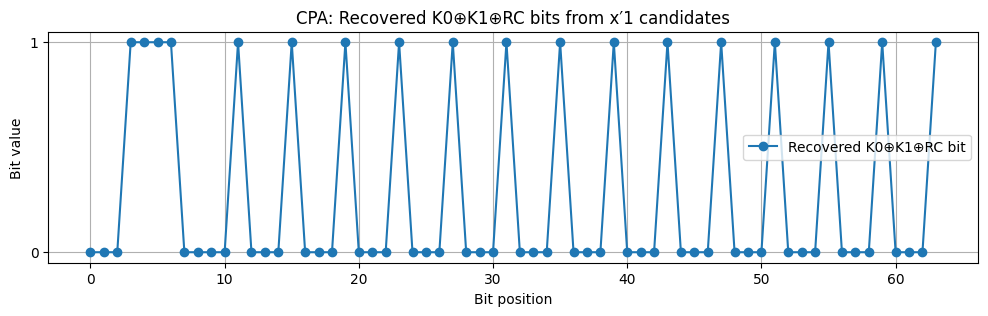

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\figure_recovered_relation_bits_CPA.png


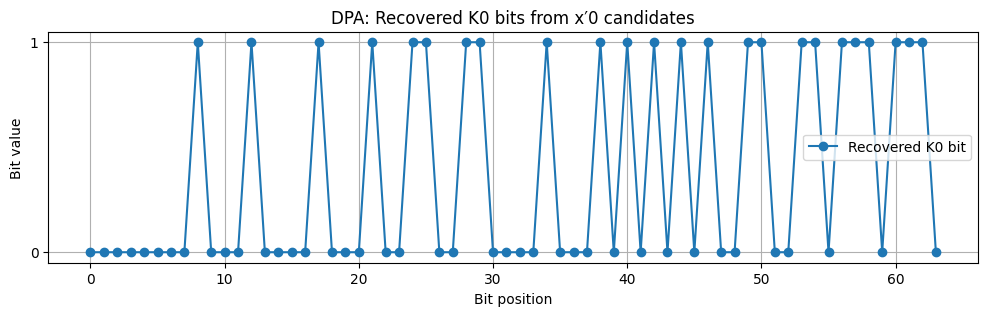

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\figure_recovered_k0_bits_DPA.png


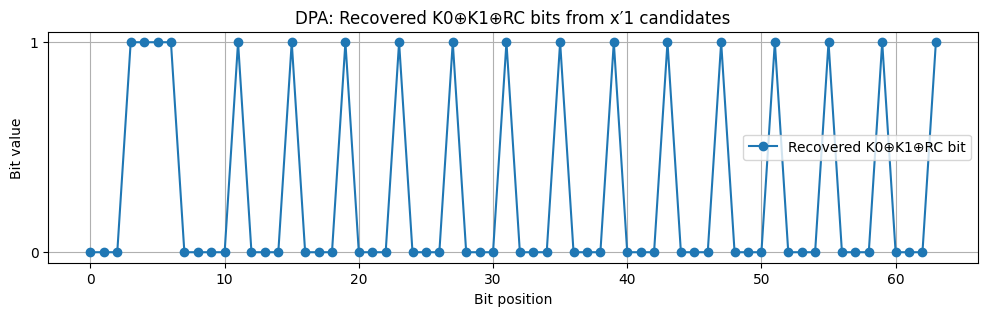

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\key_reconstruction_from_x0_x1\figure_recovered_relation_bits_DPA.png


In [10]:
for method in METHODS:
    k0_table = bit_tables[(method, "k0")]
    rel_table = bit_tables[(method, "relation")]

    plt.figure(figsize=(12, 3))
    plt.plot(k0_table["bit_position"], k0_table["recovered_bit"], marker="o", label="Recovered K0 bit")
    plt.title(f"{method}: Recovered K0 bits from x′0 candidates")
    plt.xlabel("Bit position")
    plt.ylabel("Bit value")
    plt.yticks([0, 1])
    plt.grid(True)
    plt.legend()

    out = OUT_DIR / f"figure_recovered_k0_bits_{method}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

    plt.figure(figsize=(12, 3))
    plt.plot(rel_table["bit_position"], rel_table["recovered_bit"], marker="o", label="Recovered K0⊕K1⊕RC bit")
    plt.title(f"{method}: Recovered K0⊕K1⊕RC bits from x′1 candidates")
    plt.xlabel("Bit position")
    plt.ylabel("Bit value")
    plt.yticks([0, 1])
    plt.grid(True)
    plt.legend()

    out = OUT_DIR / f"figure_recovered_relation_bits_{method}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

## 9. Interpretation guide

Use this wording carefully.

If `full_key_match = True`, you can say:

```text
Combining the x′0 and x′1 CPA/DPA candidate recovery results reconstructed the fixed 128-bit ASCON key under the first-round leakage model.
```

But still explain the intermediate meaning:

```text
x′0 reconstructs the first 64-bit key word K0.
x′1 reconstructs the K0⊕K1⊕RC relationship.
The second 64-bit key word K1 is then derived as K1 = K0⊕relation⊕RC.
```

This is stronger than saying only “x′0/x′1 candidate recovery”.